# 10 Unsupervised PC Regression

Leak-free per-fold PCA on the 20K variance-filtered gene panel, then RF on the top-100 AUC-selected PCs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from trace_path.config import Config
from trace_path.data import load_cache, build_confounder_matrix, variance_filter
from trace_path.labels import discover_tissue_category_pairs, assign_donor_labels
from trace_path.models import make_rf_model, make_lr_pipeline, _auc_feature_selection, _impute_train_fold, run_cv_with_pca
from trace_path.evaluation import plot_paired_auc_bar, plot_delta_bar

import time
from pathlib import Path as _Path
_PROGRESS_LOG = _Path('/Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/notebooks/_runlogs/nb10_progress.txt')
_PROGRESS_LOG.parent.mkdir(parents=True, exist_ok=True)
_PROGRESS_FH = open(_PROGRESS_LOG, 'w', buffering=1)  # line-buffered
_T0 = time.time()
def _mark(msg):
    t = time.time() - _T0
    line = f'[{t:7.1f}s] {msg}'
    print(line, flush=True)
    _PROGRESS_FH.write(line + '\n')
    _PROGRESS_FH.flush()
_mark('NB10 imports cell start')

Config.ensure_dirs()

X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()
rf_summary = pd.read_csv(Config.TABLES_DIR / 'cv_results_all_tissue_rf.csv')
three_way = pd.read_csv(Config.TABLES_DIR / 'cv_three_way_comparison.csv')

# Variance filter — same top 20K genes as NB07 (apples-to-apples)
X_wb_var, gene_var = variance_filter(X_wb)
print(f'Variance filter: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes')

X_conf = build_confounder_matrix(df_age, blood_subjid)

print(f'Expression matrix: {X_wb_var.shape[0]} samples x {X_wb_var.shape[1]:,} genes')
print(f'Clinical co-variate matrix: {X_conf.shape[0]} samples x {X_conf.shape[1]} features ({list(X_conf.columns)})')
_mark('NB10 imports cell DONE')

## 10.1 — Global PCA Sanity Check

How much variance do the top 800 PCs capture from the 20K variance-filtered genes?

In [ ]:
_mark('10.1 PCA-sanity START')
_t_cell = time.time()
N_PCS = 800
TOP_K_PCS = 100

scaler_check = StandardScaler()
X_scaled_check = scaler_check.fit_transform(X_wb_var)
n_comp_check = min(N_PCS, X_scaled_check.shape[0] - 1, X_scaled_check.shape[1])
pca_check = PCA(n_components=n_comp_check, random_state=Config.SEED)
pca_check.fit(X_scaled_check)

cum_var = np.cumsum(pca_check.explained_variance_ratio_)
print(f'Top {n_comp_check} PCs explain {cum_var[-1]*100:.1f}% of total variance')
print(f'Top 100 PCs explain {cum_var[99]*100:.1f}%')
print(f'Top 10 PCs explain {cum_var[9]*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_comp_check + 1), cum_var * 100, lw=1.5)
ax.axhline(cum_var[99] * 100, color='#C44E52', ls='--', lw=0.8, label=f'PC100 = {cum_var[99]*100:.1f}%')
ax.axhline(cum_var[-1] * 100, color='#4878A8', ls='--', lw=0.8, label=f'PC{n_comp_check} = {cum_var[-1]*100:.1f}%')
ax.set(xlabel='Number of PCs', ylabel='Cumulative variance explained (%)',
       title=f'PCA on {X_wb_var.shape[1]:,} variance-filtered genes ({X_wb_var.shape[0]} samples)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'pca_cumulative_variance_global.pdf', bbox_inches='tight')
plt.show()

del scaler_check, X_scaled_check, pca_check
_mark(f'10.1 PCA-sanity DONE in {time.time()-_t_cell:.1f}s')

## 10.1c — Clinical co-variate Structure on PC1/PC2

Project all whole-blood samples onto PC1-PC10 and colour by clinical co-variate.

[    2.7s] 10.1c PC1vsPC2 fig START


Saved 803 donor-sample rows -> pca_donor_scores_wb20k.csv
Variance explained PC1-PC10: PC1=29.8%, PC2=14.4%, PC3=5.1%, PC4=3.6%, PC5=2.5%, PC6=1.8%, PC7=1.6%, PC8=1.5%, PC9=1.4%, PC10=1.2%


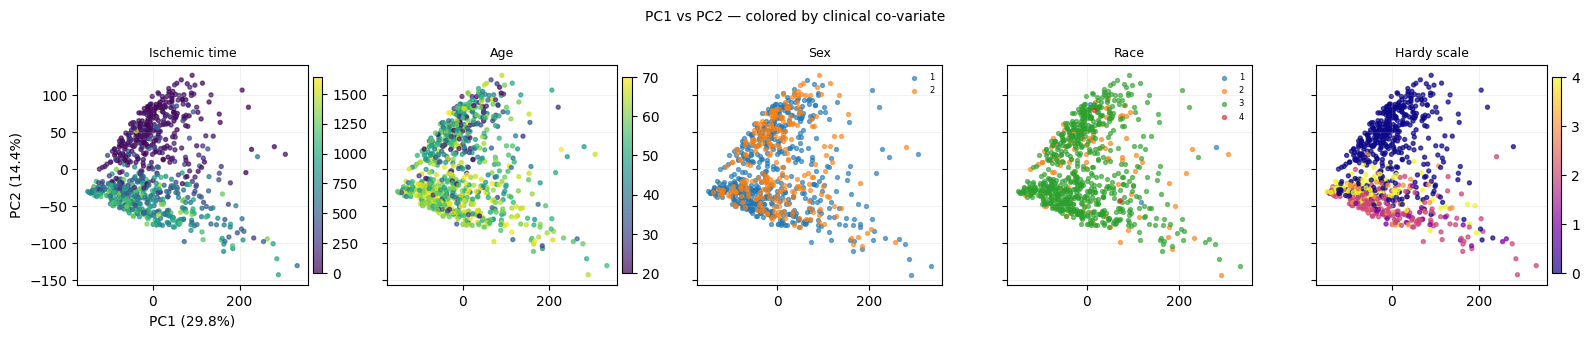

[    3.4s] 10.1c PC1vsPC2 fig DONE in 0.7s


In [3]:
_mark('10.1c PC1vsPC2 fig START')
_t_cell = time.time()
N_PC_FIG = 10

scaler_fig = StandardScaler()
X_sc_fig = scaler_fig.fit_transform(X_wb_var)
n_comp_fig = min(N_PC_FIG, X_sc_fig.shape[0] - 1, X_sc_fig.shape[1])
pca_fig = PCA(n_components=n_comp_fig, random_state=Config.SEED).fit(X_sc_fig)

scores = pca_fig.transform(X_sc_fig)
score_cols = [f"PC{i+1}" for i in range(n_comp_fig)]
donor_scores = pd.DataFrame(scores, columns=score_cols, index=X_wb_var.index)
donor_scores = donor_scores.join(X_conf, how="left")
donor_scores.index.name = "SAMPID"

donor_scores.to_csv(Config.TABLES_DIR / "pca_donor_scores_wb20k.csv")
ve = pca_fig.explained_variance_ratio_
pd.DataFrame({"pc": range(1, n_comp_fig + 1), "var_ratio": ve}).to_csv(
    Config.TABLES_DIR / "pca_explained_variance_top10.csv", index=False)

print(f"Saved {len(donor_scores)} donor-sample rows -> pca_donor_scores_wb20k.csv")
print("Variance explained PC1-PC{}: ".format(n_comp_fig) +
      ", ".join(f"PC{i+1}={ve[i]*100:.1f}%" for i in range(n_comp_fig)))

# Inline 1x5 scatter — final layout in NB14 Fig 1C.
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), sharex=True, sharey=True)
specs = [
    ("TRISCHD", "Ischemic time", "viridis", False),
    ("AGE",     "Age",           "viridis", False),
    ("SEX",     "Sex",           None,      True),
    ("RACE",    "Race",          None,      True),
    ("DTHHRDY", "Hardy scale",   "plasma",  False),
]
for ax, (col, label, cmap, is_cat) in zip(axes, specs):
    if is_cat:
        for v in sorted(donor_scores[col].dropna().unique()):
            sub = donor_scores[donor_scores[col] == v]
            ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.6, label=f"{v:g}")
        ax.legend(fontsize=6, frameon=False, loc="best")
    else:
        sc = ax.scatter(donor_scores["PC1"], donor_scores["PC2"], s=8, alpha=0.7,
                        c=donor_scores[col], cmap=cmap)
        plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(label, fontsize=9)
    ax.grid(True, alpha=0.3, lw=0.4)

axes[0].set_xlabel(f"PC1 ({ve[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({ve[1]*100:.1f}%)")
fig.suptitle("PC1 vs PC2 — colored by clinical co-variate", fontsize=10)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "pca_pc1_pc2_by_confounder.pdf", bbox_inches="tight")
plt.show()

del scaler_fig, X_sc_fig, pca_fig
_mark(f'10.1c PC1vsPC2 fig DONE in {time.time()-_t_cell:.1f}s')


## 10.1b — Sanity Check: Normalization Properties

Confirm RF Gini across PCs and per-PC absolute loadings each sum to 1 after renormalization.

In [ ]:
_mark('10.1b normalization-sanity START')
_t_cell = time.time()
# Re-fit a quick PCA for the sanity check (same as 10.1)
scaler_sc = StandardScaler()
X_sc = scaler_sc.fit_transform(X_wb_var)
pca_sc = PCA(n_components=min(N_PCS, X_sc.shape[0] - 1), random_state=Config.SEED)
pca_sc.fit(X_sc)

y_sc, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_sc = y_sc.notna()
y_sc_clean = y_sc[keep_sc].astype(int)
X_sc_sub = scaler_sc.transform(X_wb_var.loc[keep_sc])
X_pcs_sc = pca_sc.transform(X_sc_sub)

pc_cols_sc = [f'PC{i+1}' for i in range(pca_sc.n_components_)]
X_pcs_df = pd.DataFrame(X_pcs_sc, columns=pc_cols_sc, index=X_wb_var.loc[keep_sc].index)

top_pcs_sc = _auc_feature_selection(X_pcs_df, y_sc_clean, top_k=TOP_K_PCS)
X_conf_sc = X_conf.loc[keep_sc]
# One-shot sanity-check fit (no CV) — impute clinical co-variates with
# the median of this same slice. Real CV runs use train-fold imputation.
X_conf_sc = X_conf_sc.fillna(X_conf_sc.median())
X_sel = pd.concat([X_pcs_df[top_pcs_sc], X_conf_sc], axis=1)

rf_sc = make_rf_model()
rf_sc.fit(X_sel, y_sc_clean)

fi_all = rf_sc.feature_importances_
fi_pcs = fi_all[:len(top_pcs_sc)]
fi_conf = fi_all[len(top_pcs_sc):]

print('=== Sanity Check 1: RF Gini Importance Sums ===')
print(f'  Total (all {len(fi_all)} features):  {fi_all.sum():.6f}  (should be 1.0)')
print(f'  PCs only ({len(fi_pcs)} features):   {fi_pcs.sum():.6f}  (< 1, clinical co-variates absorbed {fi_conf.sum():.4f})')
print(f'  After renorm PCs to 1:     {(fi_pcs / fi_pcs.sum()).sum():.6f}')
print()

pc_idx = 0
loadings_pc1 = pca_sc.components_[pc_idx, :]

abs_sum = np.sum(np.abs(loadings_pc1))
abs_norm_sum = np.sum(np.abs(loadings_pc1) / abs_sum)

print('=== Sanity Check 2: Absolute Loading Norms (PC1) ===')
print(f'  Σ |loading|:      {abs_sum:.4f}  (>> 1, not normalized)')
print(f'  After |L|/Σ|L|:   {abs_norm_sum:.6f}  (= 1.0 after normalization)')
del scaler_sc, X_sc, pca_sc, rf_sc
_mark(f'10.1b normalization-sanity DONE in {time.time()-_t_cell:.1f}s')

In [5]:
# run_cv_with_pca moved to trace_path/models.py to support the
# multi-threshold covariate-orthogonal PC sweep. Imported above.


## 10.2 — Single-Feature AUC: Liver | Cirrhosis

For Liver | cirrhosis, fit PCA on 20K variance-filtered genes → 800 PCs, then
compute the **univariate AUC** of each PC individually against the label.

In [ ]:
y_demo, _, n_pos_demo, n_neg_demo = assign_donor_labels(
    df_meta_url, 'Liver', 'cirrhosis', blood_subjid
)
keep_demo = y_demo.notna()
y_demo_clean = y_demo[keep_demo].astype(int)
X_demo = X_wb_var.loc[keep_demo]
print(f'Liver | cirrhosis: {n_pos_demo} positive, {n_neg_demo} negative, {len(y_demo_clean)} total')

scaler_demo = StandardScaler()
X_demo_scaled = scaler_demo.fit_transform(X_demo)
n_comp_demo = min(N_PCS, X_demo_scaled.shape[0] - 1, X_demo_scaled.shape[1])
pca_demo = PCA(n_components=n_comp_demo, random_state=Config.SEED)
X_demo_pcs = pca_demo.fit_transform(X_demo_scaled)

pc_aucs = []
for i in range(n_comp_demo):
    auc_i = roc_auc_score(y_demo_clean, X_demo_pcs[:, i])
    # Flip if below 0.5 (direction doesn't matter for univariate screening)
    pc_aucs.append(max(auc_i, 1 - auc_i))

pc_aucs = np.array(pc_aucs)
top_idx = np.argsort(pc_aucs)[::-1]

print(f'\nTop 10 PCs by univariate AUC:')
for rank, idx in enumerate(top_idx[:10], 1):
    print(f'  {rank}. PC{idx+1}: AUC = {pc_aucs[idx]:.3f}')

print(f'\nPCs with AUC > 0.55: {(pc_aucs > 0.55).sum()} / {n_comp_demo}')
print(f'PCs with AUC > Config.AUC_THRESH ({Config.AUC_THRESH:.2f}): '
      f'{(pc_aucs > Config.AUC_THRESH).sum()} / {n_comp_demo}')

del scaler_demo, X_demo_scaled, pca_demo, X_demo_pcs

## 10.2b — CV-Folded Univariate PC AUC for Liver | Cirrhosis

Mean +/- SD univariate AUC per PC across 5 folds; global PCA fit is descriptive-only.

In [7]:
_mark('10.2b CV-univariate PC AUC START')
_t_cell = time.time()
# CV-folded univariate AUC for each PC.  PCA is fit once globally on the
# Liver|cirrhosis subset (so PC identity is stable across folds — a global
# fit leaks test-fold info into the PC directions, but this section is
# descriptive, not predictive).  Predictive PC numbers in 10.3+ use the
# leak-free per-fold PCA.
N_PCS_UV = 800

y_uv, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_uv = y_uv.notna()
y_uv_clean = y_uv[keep_uv].astype(int)
g_uv = blood_subjid[keep_uv].astype(str)
X_uv = X_wb_var.loc[keep_uv]

scaler_uv = StandardScaler()
X_uv_scaled = scaler_uv.fit_transform(X_uv)
n_comp_uv = min(N_PCS_UV, X_uv_scaled.shape[0] - 1, X_uv_scaled.shape[1])
pca_uv = PCA(n_components=n_comp_uv, random_state=Config.SEED)
X_uv_pcs = pca_uv.fit_transform(X_uv_scaled)

# Covariate-orthogonal PC filter (Sanju spec): drop PCs with max-AUC > headline threshold
from trace_path.models import _compute_pc_covariate_aucs, _drop_covariate_aligned_pcs
X_conf_uv = X_conf.loc[keep_uv]
_pc_cols_uv = [f'PC{i+1}' for i in range(n_comp_uv)]
_pcs_uv_df = pd.DataFrame(X_uv_pcs, columns=_pc_cols_uv, index=X_uv.index)
_cov_aucs_uv = _compute_pc_covariate_aucs(_pcs_uv_df, X_conf_uv)
_keep_mask_uv = _drop_covariate_aligned_pcs(_cov_aucs_uv, Config.COVARIATE_ORTHO_AUC_THRESH)
_keep_pc_idx_uv = [i for i, c in enumerate(_pc_cols_uv) if _keep_mask_uv[c]]
print(f'10.2b: orthogonality filter kept {len(_keep_pc_idx_uv)}/{n_comp_uv} PCs at threshold {Config.COVARIATE_ORTHO_AUC_THRESH}')
X_uv_pcs = X_uv_pcs[:, _keep_pc_idx_uv]
n_comp_uv = len(_keep_pc_idx_uv)
# Remap pc indices so saved file uses 1-based survivor IDs that align with the saved PCA loadings
_pc_orig_idx_uv = [i + 1 for i in _keep_pc_idx_uv]  # original 1-based PC numbers among survivors

cv_uv = StratifiedGroupKFold(
    n_splits=Config.N_SPLITS, shuffle=True, random_state=Config.SEED)
fold_aucs_uv = np.zeros((Config.N_SPLITS, n_comp_uv))
for fold, (tr, te) in enumerate(cv_uv.split(X_uv_pcs, y_uv_clean, groups=g_uv)):
    y_te = y_uv_clean.iloc[te].values
    for pc_i in range(n_comp_uv):
        a = roc_auc_score(y_te, X_uv_pcs[te, pc_i])
        # Direction-agnostic — a PC's sign is arbitrary
        fold_aucs_uv[fold, pc_i] = max(a, 1 - a)

mean_uv = fold_aucs_uv.mean(axis=0)
std_uv  = fold_aucs_uv.std(axis=0)

uv_df = (pd.DataFrame({'pc': _pc_orig_idx_uv,
                       'mean_auc': mean_uv, 'std_auc': std_uv})
           .sort_values('mean_auc', ascending=False)
           .reset_index(drop=True))
uv_df.to_csv(Config.TABLES_DIR / 'liver_cirrhosis_pc_univariate_auc.csv',
             index=False)
print(f'Saved {len(uv_df)} PCs -> liver_cirrhosis_pc_univariate_auc.csv')
print('\nTop 10 PCs by CV-mean univariate AUC:')
display(uv_df.head(10))

del scaler_uv, X_uv_scaled, pca_uv, X_uv_pcs, fold_aucs_uv
_mark(f'10.2b CV-univariate PC AUC DONE in {time.time()-_t_cell:.1f}s')


[    7.5s] 10.2b CV-univariate PC AUC START


10.2b: orthogonality filter kept 427/434 PCs at threshold 0.7


Saved 427 PCs -> liver_cirrhosis_pc_univariate_auc.csv

Top 10 PCs by CV-mean univariate AUC:


,pc,mean_auc,std_auc
0,1,0.710470,0.098115
1,13,0.698452,0.107128
2,434,0.669789,0.079541
3,374,0.668013,0.064730
4,305,0.660423,0.083990
5,7,0.659978,0.103412
6,388,0.652471,0.051139
7,4,0.651614,0.065211
8,10,0.646231,0.101262
9,65,0.644687,0.036841


[   13.0s] 10.2b CV-univariate PC AUC DONE in 5.6s


## 10.2c — PC-RF Gini Importance for Liver | Cirrhosis (Figure 3 panel A)

Mean +/- SD Gini per PC across 5 folds on the top-100 univariate-AUC PCs.

In [ ]:
_mark('10.2c PC-RF Gini Liver-cir START')
_t_cell = time.time()
# Re-prep Liver | cirrhosis labels and data (variables from §10.2b were del'd)
y_g, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_g = y_g.notna()
y_g = y_g[keep_g].astype(int)
g_g = blood_subjid[keep_g].astype(str)
X_g = X_wb_var.loc[keep_g]

# Global PCA (descriptive — same approach as §10.2b)
N_PCS_GINI = 800
scaler_g = StandardScaler()
X_g_scaled = scaler_g.fit_transform(X_g)
n_comp_g = min(N_PCS_GINI, X_g_scaled.shape[0] - 1, X_g_scaled.shape[1])
pca_g = PCA(n_components=n_comp_g, random_state=Config.SEED)
X_g_pcs = pca_g.fit_transform(X_g_scaled)

# Covariate-orthogonal PC filter (Sanju spec): drop PCs with max-AUC > headline threshold
from trace_path.models import _compute_pc_covariate_aucs, _drop_covariate_aligned_pcs
X_conf_g = X_conf.loc[keep_g]
_pc_cols_g = [f'PC{i+1}' for i in range(n_comp_g)]
_pcs_g_df = pd.DataFrame(X_g_pcs, columns=_pc_cols_g, index=X_g.index)
_cov_aucs_g = _compute_pc_covariate_aucs(_pcs_g_df, X_conf_g)
_keep_mask_g = _drop_covariate_aligned_pcs(_cov_aucs_g, Config.COVARIATE_ORTHO_AUC_THRESH)
_keep_pc_idx_g = [i for i, c in enumerate(_pc_cols_g) if _keep_mask_g[c]]
print(f'10.2c: orthogonality filter kept {len(_keep_pc_idx_g)}/{n_comp_g} PCs at threshold {Config.COVARIATE_ORTHO_AUC_THRESH}')
X_g_pcs = X_g_pcs[:, _keep_pc_idx_g]
n_comp_g = len(_keep_pc_idx_g)
_pc_orig_idx_g = [i + 1 for i in _keep_pc_idx_g]

# Pick top 100 PCs by globally-computed univariate CV AUC (from §10.2b)
uv = pd.read_csv(Config.TABLES_DIR / 'liver_cirrhosis_pc_univariate_auc.csv')
top100_pcs = uv.head(100)['pc'].astype(int).values  # 1-indexed original PC numbers
_orig_to_col_g = {orig: col for col, orig in enumerate(_pc_orig_idx_g)}
top100_pcs = np.array([p for p in top100_pcs if p in _orig_to_col_g])
top100_col_idx = [_orig_to_col_g[p] for p in top100_pcs]
X_g_pcs100 = X_g_pcs[:, top100_col_idx]
print(f'10.2c: top-100 univariate-AUC PCs intersected with orthogonality survivors: {len(top100_pcs)} PCs')

cv_g = StratifiedGroupKFold(
    n_splits=Config.N_SPLITS, shuffle=True, random_state=Config.SEED)
fold_gini = np.zeros((Config.N_SPLITS, len(top100_pcs)))
for fold, (tr, te) in enumerate(cv_g.split(X_g_pcs100, y_g, groups=g_g)):
    rf = make_rf_model()
    rf.fit(X_g_pcs100[tr], y_g.iloc[tr])
    fold_gini[fold] = rf.feature_importances_

mean_gini = fold_gini.mean(axis=0)
std_gini  = fold_gini.std(axis=0)

gini_df = (pd.DataFrame({'pc': top100_pcs,
                         'mean_gini': mean_gini,
                         'std_gini':  std_gini})
             .sort_values('mean_gini', ascending=False)
             .reset_index(drop=True))
gini_df.to_csv(Config.TABLES_DIR / 'liver_cirrhosis_pc_rf_gini.csv', index=False)
print(f'Saved {len(gini_df)} PCs -> liver_cirrhosis_pc_rf_gini.csv')
print('\nTop 10 PCs by mean Gini importance:')
display(gini_df.head(10))

del scaler_g, X_g_scaled, pca_g, X_g_pcs, X_g_pcs100, fold_gini
_mark(f'10.2c PC-RF Gini Liver-cir DONE in {time.time()-_t_cell:.1f}s')

## 10.3 — Run All Pairs

Leak-free PC-based CV on all tissue × pathology pairs (20K variance-filtered genes).

In [9]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f'{len(pairs_df)} tissue x category pairs across {pairs_df["tissue"].nunique()} tissue types\n')

ORTHO_THRESHOLDS = Config.COVARIATE_ORTHO_THRESHOLDS
print(f'Covariate-orthogonal sweep thresholds: {ORTHO_THRESHOLDS} (headline = {Config.COVARIATE_ORTHO_AUC_THRESH})')

pc_results_by_thresh = {t: [] for t in ORTHO_THRESHOLDS}
dropped_pcs_records = []  # per-fold-per-threshold diagnostics

for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]
    X_covar_sub = X_conf.loc[keep]  # for orthogonality filter (5 covariates)

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')
    _mark(f'pair {i+1:2d}/{len(pairs_df)} START (PC-only) {tag}')
    _t_pair = time.time()
    res = run_cv_with_pca(
        X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
        X_covar=X_covar_sub,
        ortho_thresholds=ORTHO_THRESHOLDS,
        tag=tag,
    )
    for t, d in res['per_threshold'].items():
        pc_results_by_thresh[t].append({
            'tissue': tissue, 'category': cat,
            'auc_pc': d['mean_auc'], 'std_pc': d['std_auc'],
        })
    _mark(f'pair {i+1:2d}/{len(pairs_df)} DONE  (PC-only) {tag} in {time.time()-_t_pair:.1f}s')
    for r in res['dropped_pcs']:
        r['tissue'] = tissue
        r['category'] = cat
        dropped_pcs_records.append(r)

# Per-threshold DataFrames; headline (0.70) keeps the old `pc_auc` variable name
pc_auc_by_thresh = {t: pd.DataFrame(rows) for t, rows in pc_results_by_thresh.items()}
pc_auc = pc_auc_by_thresh[Config.COVARIATE_ORTHO_AUC_THRESH]
print(f'\nCompleted {len(pc_auc)} PC-only models per threshold')
print(f'Headline (t={Config.COVARIATE_ORTHO_AUC_THRESH}) mean PC AUC: {pc_auc["auc_pc"].mean():.3f}')


59 tissue x category pairs across 20 tissue types

Covariate-orthogonal sweep thresholds: [0.65, 0.7, 0.75] (headline = 0.7)
[ 1/59] Adipose - Subcutaneous | fibrosis  (n_pos=228, n_neg=33)
[   19.5s] pair  1/59 START (PC-only) Adipose - Subcutaneous | fibrosis


    Adipose - Subcutaneous | fibrosis [t=0.65: 0.524±0.046] [t=0.70: 0.460±0.094] [t=0.75: 0.503±0.120]
[   35.4s] pair  1/59 DONE  (PC-only) Adipose - Subcutaneous | fibrosis in 15.9s


[ 2/59] Adipose - Visceral (Omentum) | fibrosis  (n_pos=118, n_neg=55)
[   35.4s] pair  2/59 START (PC-only) Adipose - Visceral (Omentum) | fibrosis


    Adipose - Visceral (Omentum) | fibrosis [t=0.65: 0.462±0.037] [t=0.70: 0.521±0.049] [t=0.75: 0.492±0.110]
[   47.2s] pair  2/59 DONE  (PC-only) Adipose - Visceral (Omentum) | fibrosis in 11.8s


[ 3/59] Artery - Aorta | atherosis  (n_pos=195, n_neg=276)
[   47.2s] pair  3/59 START (PC-only) Artery - Aorta | atherosis


...

[58/59] Thyroid | hashimoto  (n_pos=56, n_neg=403)
[ 1571.0s] pair 58/59 START (PC-only) Thyroid | hashimoto


    Thyroid | hashimoto [t=0.65: 0.516±0.118] [t=0.70: 0.533±0.146] [t=0.75: 0.524±0.129]
[ 1600.1s] pair 58/59 DONE  (PC-only) Thyroid | hashimoto in 29.1s


[59/59] Thyroid | goiter  (n_pos=50, n_neg=409)
[ 1600.1s] pair 59/59 START (PC-only) Thyroid | goiter


    Thyroid | goiter [t=0.65: 0.453±0.134] [t=0.70: 0.500±0.093] [t=0.75: 0.500±0.116]
[ 1630.1s] pair 59/59 DONE  (PC-only) Thyroid | goiter in 30.0s



Completed 59 PC-only models per threshold
Headline (t=0.7) mean PC AUC: 0.531


## 10.4 — Liver | Cirrhosis in Context

Where does the Liver | cirrhosis pair rank against the rest of the screen?

In [10]:
pc_auc_sorted = pc_auc.copy()
pc_auc_sorted['label'] = pc_auc_sorted['tissue'] + ' | ' + pc_auc_sorted['category']
pc_auc_sorted = pc_auc_sorted.sort_values('auc_pc', ascending=False).reset_index(drop=True)

rank = pc_auc_sorted[pc_auc_sorted['label'] == 'Liver | cirrhosis'].index[0] + 1
auc_val = pc_auc_sorted.loc[pc_auc_sorted['label'] == 'Liver | cirrhosis', 'auc_pc'].values[0]
print(f'Liver | cirrhosis PC AUC: {auc_val:.3f}  (rank {rank}/{len(pc_auc_sorted)})')

Liver | cirrhosis PC AUC: 0.762  (rank 1/59)


## 10.5 — PC AUC Bar Chart

Horizontal bar chart of PC-based AUC across the full screened set of tissue × pathology pairs, sorted by AUC.

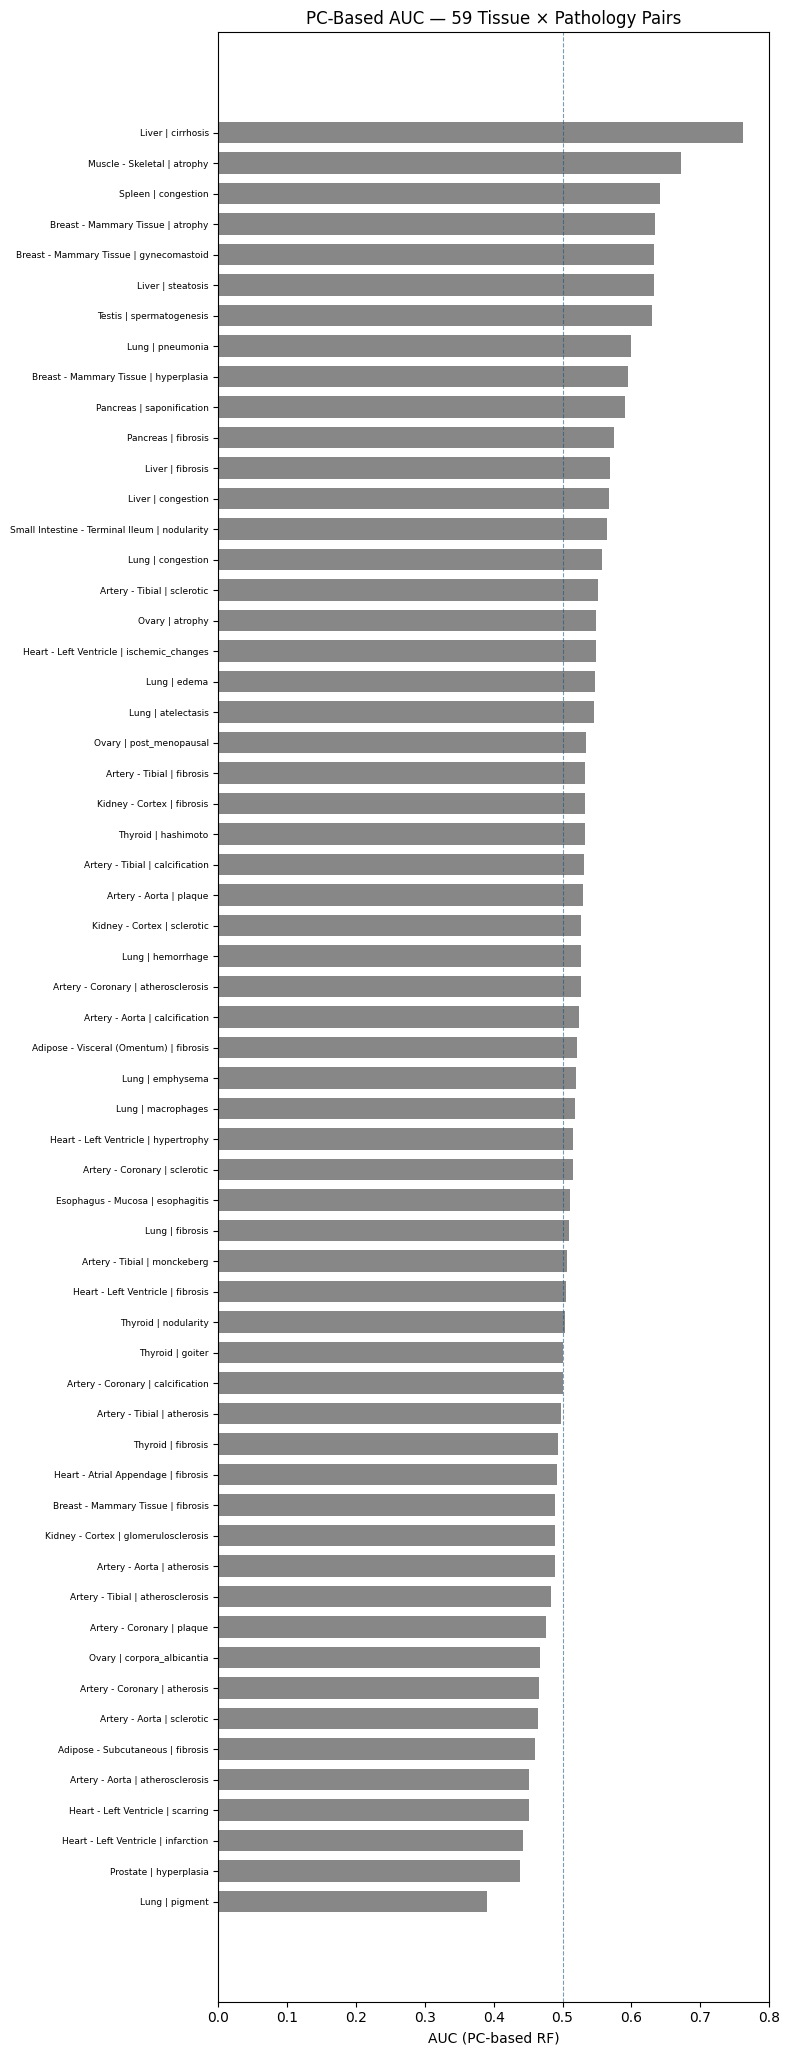

In [11]:
plot_df = pc_auc.copy()
plot_df['label'] = plot_df['tissue'] + ' | ' + plot_df['category']
plot_df = plot_df.sort_values('auc_pc', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(10, len(plot_df) * 0.35)))
ax.barh(range(len(plot_df)), plot_df['auc_pc'], color='#555555', height=0.7, alpha=0.7)
ax.axvline(0.5, ls='--', lw=0.8, color="#13527E92")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=6.5)
ax.set_xlabel('AUC (PC-based RF)')
ax.set_title(f'PC-Based AUC — {len(plot_df)} Tissue × Pathology Pairs')
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'pc_auc_bar.pdf', bbox_inches='tight')
plt.show()

## 10.6 — PC + Clinical co-variates (All Pairs)

Same leak-free CV as 10.3, but clinical co-variates (SEX, AGE, RACE, DTHHRDY, TRISCHD) are
appended to the selected PCs before training the RF.

In [12]:
pc_conf_results_by_thresh = {t: [] for t in ORTHO_THRESHOLDS}
oof_by_pair = {}  # (tissue, category) -> OOF score Series indexed by SAMPID (headline threshold only, for §10.12 specificity)

for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]
    X_conf_sub = X_conf.loc[keep]

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')
    _mark(f'pair {i+1:2d}/{len(pairs_df)} START (PC+conf) {tag}')
    _t_pair = time.time()
    res = run_cv_with_pca(
        X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
        X_conf_sub=X_conf_sub,
        X_covar=X_conf_sub,
        ortho_thresholds=ORTHO_THRESHOLDS,
        tag=tag,
    )
    for t, d in res['per_threshold'].items():
        pc_conf_results_by_thresh[t].append({
            'tissue': tissue, 'category': cat,
            'auc_pc_conf': d['mean_auc'], 'std_pc_conf': d['std_auc'],
        })
        if t == Config.COVARIATE_ORTHO_AUC_THRESH:
            oof_by_pair[(tissue, cat)] = pd.Series(d['oof'], index=y_clean.index, name=tag)
    _mark(f'pair {i+1:2d}/{len(pairs_df)} DONE  (PC+conf) {tag} in {time.time()-_t_pair:.1f}s')

pc_conf_auc_by_thresh = {t: pd.DataFrame(rows) for t, rows in pc_conf_results_by_thresh.items()}
pc_conf_auc = pc_conf_auc_by_thresh[Config.COVARIATE_ORTHO_AUC_THRESH]
print(f'\nCompleted {len(pc_conf_auc)} PC + co-variates models per threshold')
print(f'Headline (t={Config.COVARIATE_ORTHO_AUC_THRESH}) mean PC + co-variates AUC: {pc_conf_auc["auc_pc_conf"].mean():.3f}')


[ 1/59] Adipose - Subcutaneous | fibrosis  (n_pos=228, n_neg=33)
[ 1630.5s] pair  1/59 START (PC+conf) Adipose - Subcutaneous | fibrosis


    Adipose - Subcutaneous | fibrosis [t=0.65: 0.511±0.057] [t=0.70: 0.495±0.112] [t=0.75: 0.460±0.113]
[ 1647.1s] pair  1/59 DONE  (PC+conf) Adipose - Subcutaneous | fibrosis in 16.7s


[ 2/59] Adipose - Visceral (Omentum) | fibrosis  (n_pos=118, n_neg=55)
[ 1647.2s] pair  2/59 START (PC+conf) Adipose - Visceral (Omentum) | fibrosis


    Adipose - Visceral (Omentum) | fibrosis [t=0.65: 0.462±0.044] [t=0.70: 0.498±0.030] [t=0.75: 0.509±0.040]
[ 1659.6s] pair  2/59 DONE  (PC+conf) Adipose - Visceral (Omentum) | fibrosis in 12.5s


[ 3/59] Artery - Aorta | atherosis  (n_pos=195, n_neg=276)
[ 1659.7s] pair  3/59 START (PC+conf) Artery - Aorta | atherosis


...

[58/59] Thyroid | hashimoto  (n_pos=56, n_neg=403)
[ 3205.8s] pair 58/59 START (PC+conf) Thyroid | hashimoto


    Thyroid | hashimoto [t=0.65: 0.535±0.132] [t=0.70: 0.541±0.127] [t=0.75: 0.529±0.141]
[ 3235.0s] pair 58/59 DONE  (PC+conf) Thyroid | hashimoto in 29.2s


[59/59] Thyroid | goiter  (n_pos=50, n_neg=409)
[ 3235.0s] pair 59/59 START (PC+conf) Thyroid | goiter


    Thyroid | goiter [t=0.65: 0.500±0.131] [t=0.70: 0.500±0.095] [t=0.75: 0.510±0.117]
[ 3264.3s] pair 59/59 DONE  (PC+conf) Thyroid | goiter in 29.2s



Completed 59 PC + co-variates models per threshold
Headline (t=0.7) mean PC + co-variates AUC: 0.563


## 10.7 — Comparison: PC + co-variates vs Co-variates only

Side-by-side bar chart showing PC + co-variates AUC vs Co-variates only AUC (from NB09).
This shows how much the PCs add on top of demographics.

Mean Co-variates only AUC: 0.567
Mean PC + co-variates AUC:   0.563


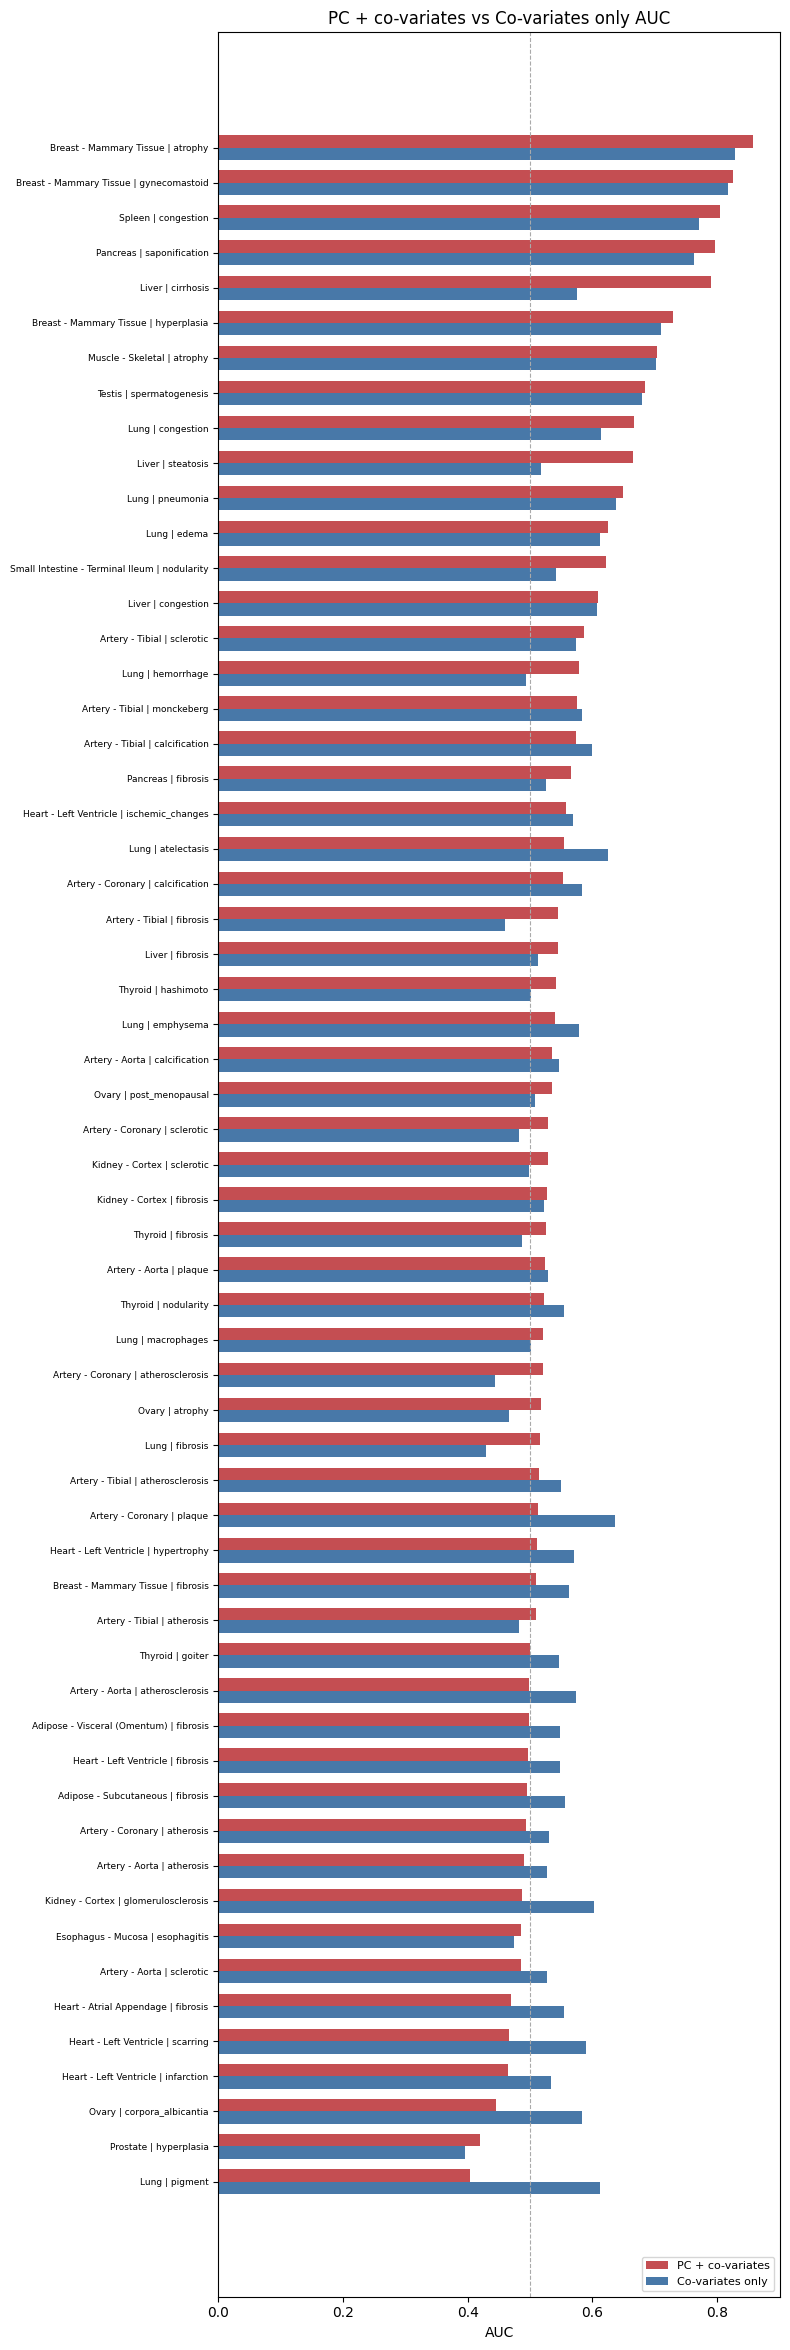

In [13]:
# Merge PC + co-variates with co-variates only AUC from three_way (NB09)
comp = pc_conf_auc.merge(
    three_way[['tissue', 'category', 'auc_conf']],
    on=['tissue', 'category']
)
comp = comp.merge(pc_auc, on=['tissue', 'category'])
comp['delta_pc'] = comp['auc_pc_conf'] - comp['auc_conf']

print(f'Mean Co-variates only AUC: {comp["auc_conf"].mean():.3f}')
print(f'Mean PC + co-variates AUC:   {comp["auc_pc_conf"].mean():.3f}')

_ = plot_paired_auc_bar(
    comp, auc_col_a='auc_pc_conf', auc_col_b='auc_conf',
    label_a='PC + co-variates', label_b='Co-variates only',
    title='PC + co-variates vs Co-variates only AUC',
    save_path=Config.FIGURES_DIR / 'pc_conf_vs_conf_bar.pdf'
)

## 10.8 — ΔAUC: PC Gain Over Clinical co-variates

How much do PCs add beyond demographics alone?

Mean Δ (PC gain over conf): -0.0041


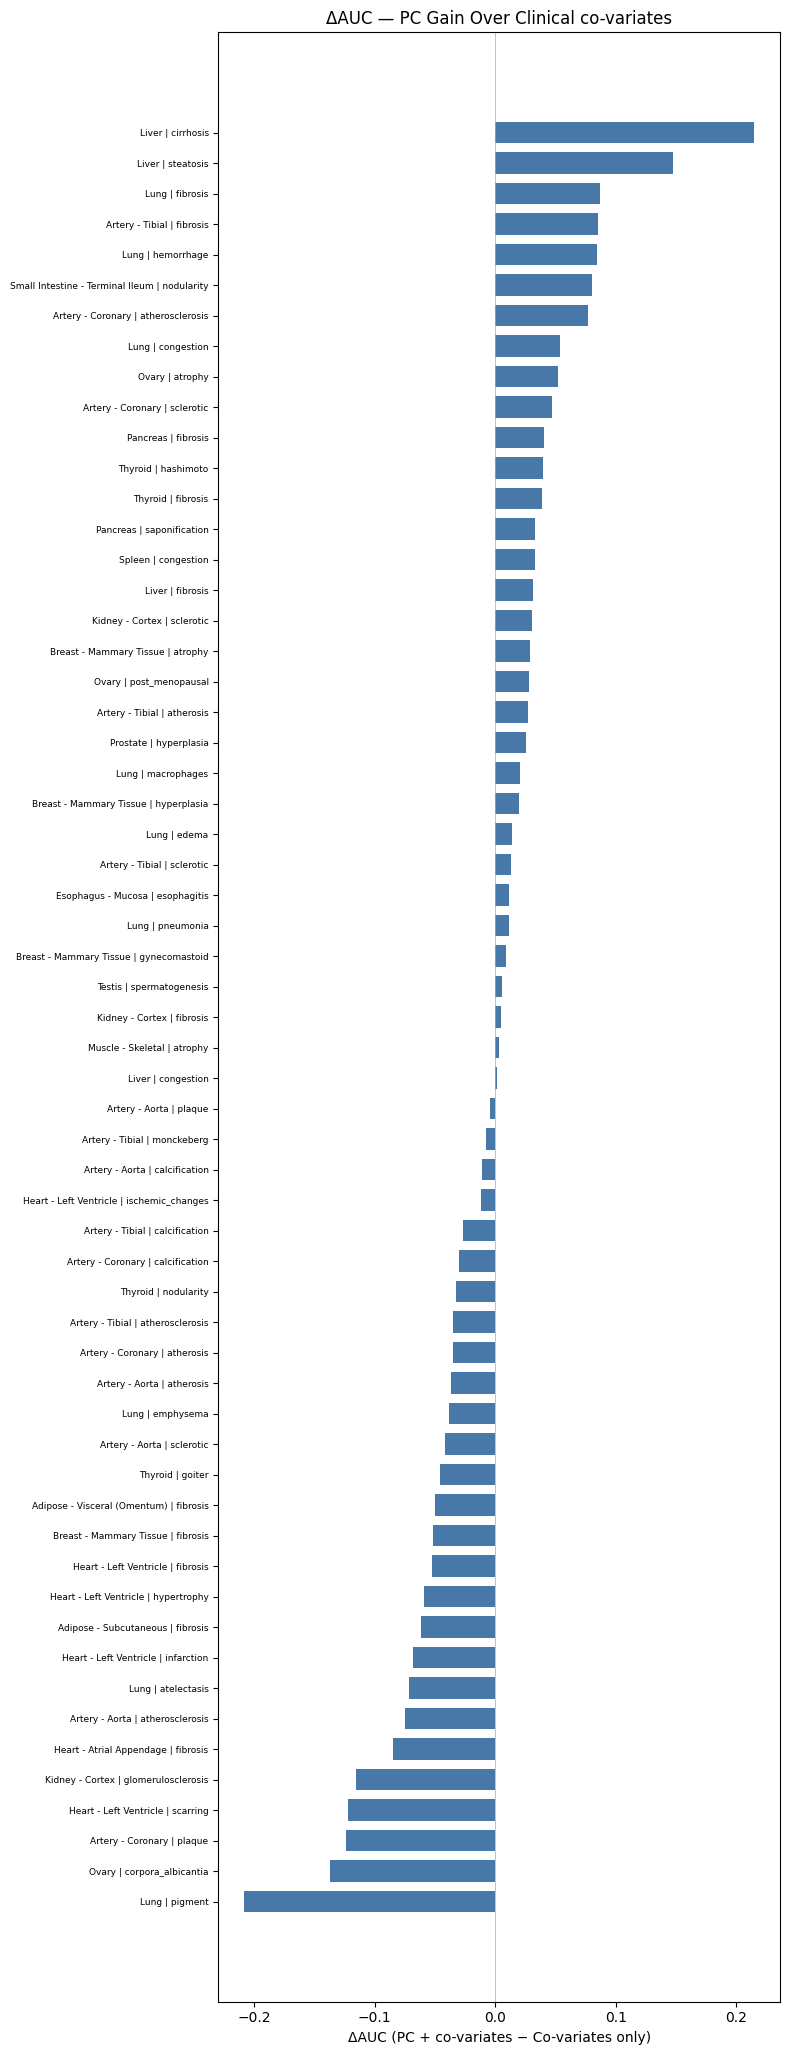

In [14]:
delta_df = comp[['tissue', 'category', 'auc_pc', 'auc_pc_conf', 'auc_conf', 'delta_pc']].copy()

print(f'Mean Δ (PC gain over conf): {delta_df["delta_pc"].mean():.4f}')

_ = plot_delta_bar(
    delta_df, delta_col='delta_pc',
    title='ΔAUC — PC Gain Over Clinical co-variates',
    xlabel='ΔAUC (PC + co-variates − Co-variates only)',
    save_path=Config.FIGURES_DIR / 'delta_auc_pc_over_conf.pdf'
)

## 10.9 — Export

In [ ]:
_mark('NB10 export start')
# Save per-threshold sweep CSVs + headline (0.70) to the canonical filename.
for t in ORTHO_THRESHOLDS:
    pc_t = pc_auc_by_thresh[t]
    pcc_t = pc_conf_auc_by_thresh[t]
    comp_t = pcc_t.merge(
        three_way[['tissue', 'category', 'auc_conf']],
        on=['tissue', 'category'],
    ).merge(pc_t, on=['tissue', 'category'])
    comp_t['delta_pc'] = comp_t['auc_pc_conf'] - comp_t['auc_conf']
    out = comp_t[['tissue', 'category', 'auc_pc', 'std_pc', 'auc_pc_conf', 'std_pc_conf', 'auc_conf', 'delta_pc']].copy()
    out['label'] = out['tissue'] + ' | ' + out['category']
    out = out.sort_values('delta_pc', ascending=False).reset_index(drop=True)
    out.to_csv(Config.TABLES_DIR / f'pc_auc_results_thresh_{t:.2f}.csv', index=False)
    print(f'Saved threshold {t:.2f}: {len(out)} rows → output/tables/pc_auc_results_thresh_{t:.2f}.csv')
    if t == Config.COVARIATE_ORTHO_AUC_THRESH:
        out.to_csv(Config.TABLES_DIR / 'pc_auc_results.csv', index=False)
        print(f'  -> also saved as headline pc_auc_results.csv')

dropped_df = pd.DataFrame(dropped_pcs_records)
dropped_df.to_csv(Config.TABLES_DIR / 'covariate_dropped_pcs.csv', index=False)
print(f'Saved {len(dropped_df)} per-fold-per-threshold dropped-PC records -> output/tables/covariate_dropped_pcs.csv')

# Downstream cells reference `comp` and `export_df`
export_df = pd.read_csv(Config.TABLES_DIR / 'pc_auc_results.csv')
comp = export_df.copy()
display(export_df)

_mark('NB10 export DONE — pipeline complete')
_PROGRESS_FH.close()

In [16]:
n_qual = ((comp['auc_pc_conf'] >= Config.AUC_THRESH) & (comp['delta_pc'] >= Config.DELTA_THRESH)).sum()
print(f"Qualifying models (AUC_THRESH={Config.AUC_THRESH:.2f}, DELTA_THRESH={Config.DELTA_THRESH:.2f}): {n_qual} / {len(comp)}")


Qualifying models (AUC_THRESH=0.60, DELTA_THRESH=0.05): 4 / 59


## 10.10 — PC-LR (Logistic Regression on PCs)

Same PC features as §10.3/§10.6 but with logistic regression, expression-only and with clinical co-variates.

In [17]:
pc_lr_results = []
pc_lr_conf_results = []

for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]
    X_conf_sub = X_conf.loc[keep]

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')

    res_lr = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
                             tag=f'{tag} [LR]', model_factory=make_lr_pipeline)
    pc_lr_results.append({'tissue': tissue, 'category': cat,
                          'auc_pc_lr': res_lr['mean_auc'],
                          'std_pc_lr': res_lr['std_auc']})

    res_lr_conf = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
                                  X_conf_sub=X_conf_sub,
                                  tag=f'{tag} [LR+conf]',
                                  model_factory=make_lr_pipeline)
    pc_lr_conf_results.append({'tissue': tissue, 'category': cat,
                               'auc_pc_lr_conf': res_lr_conf['mean_auc'],
                               'std_pc_lr_conf': res_lr_conf['std_auc']})

pc_lr_df = (pd.DataFrame(pc_lr_results)
              .merge(pd.DataFrame(pc_lr_conf_results), on=['tissue', 'category']))
pc_lr_df.to_csv(Config.TABLES_DIR / 'pc_lr_results.csv', index=False)
print(f'\nCompleted {len(pc_lr_df)} PC-LR + PC-LR+conf models')
print(f'Mean PC-LR AUC:        {pc_lr_df["auc_pc_lr"].mean():.3f}')
print(f'Mean PC-LR + conf AUC: {pc_lr_df["auc_pc_lr_conf"].mean():.3f}')
print(f'Saved -> output/tables/pc_lr_results.csv')

[ 1/59] Adipose - Subcutaneous | fibrosis  (n_pos=228, n_neg=33)


    Adipose - Subcutaneous | fibrosis [LR] Mean AUC = 0.525 +/- 0.134


    Adipose - Subcutaneous | fibrosis [LR+conf] Mean AUC = 0.546 +/- 0.152
[ 2/59] Adipose - Visceral (Omentum) | fibrosis  (n_pos=118, n_neg=55)


    Adipose - Visceral (Omentum) | fibrosis [LR] Mean AUC = 0.592 +/- 0.065


    Adipose - Visceral (Omentum) | fibrosis [LR+conf] Mean AUC = 0.581 +/- 0.050
[ 3/59] Artery - Aorta | atherosis  (n_pos=195, n_neg=276)


...

    Thyroid | nodularity [LR+conf] Mean AUC = 0.465 +/- 0.068
[58/59] Thyroid | hashimoto  (n_pos=56, n_neg=403)


    Thyroid | hashimoto [LR] Mean AUC = 0.453 +/- 0.081


    Thyroid | hashimoto [LR+conf] Mean AUC = 0.453 +/- 0.074
[59/59] Thyroid | goiter  (n_pos=50, n_neg=409)


    Thyroid | goiter [LR] Mean AUC = 0.482 +/- 0.088


    Thyroid | goiter [LR+conf] Mean AUC = 0.504 +/- 0.100

Completed 59 PC-LR + PC-LR+conf models
Mean PC-LR AUC:        0.556
Mean PC-LR + conf AUC: 0.572
Saved -> output/tables/pc_lr_results.csv


## 10.11 — Liver six-model summaries (used by NB17 Fig S3)


In [ ]:
# Combines LR raw (NB05), RF raw (NB07), PC-LR/PC-RF (this NB) into a per-pair table used by NB17 Fig S3.
import pandas as pd

lr_raw_df = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")
rf_raw_df = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")

def _row(df, tissue, cat):
    sub = df[(df["tissue"] == tissue) & (df["category"] == cat)]
    return sub.iloc[0] if len(sub) else None

def build_six_model(tissue, cat):
    lr = _row(lr_raw_df, tissue, cat)
    rf = _row(rf_raw_df, tissue, cat)
    pcr = _row(comp, tissue, cat)        # has auc_pc, std_pc, auc_pc_conf, std_pc_conf
    pcl = _row(pc_lr_df, tissue, cat)    # has auc_pc_lr, std_pc_lr, auc_pc_lr_conf, std_pc_lr_conf
    if any(x is None for x in [lr, rf, pcr, pcl]):
        return None
    return pd.DataFrame([
        {"model": "LR raw",               "mean_auc": lr["mean_auc"],       "std_auc": lr["std_auc"]},
        {"model": "RF raw",               "mean_auc": rf["mean_auc"],       "std_auc": rf["std_auc"]},
        {"model": "PC-LR (expr)",         "mean_auc": pcl["auc_pc_lr"],     "std_auc": pcl["std_pc_lr"]},
        {"model": "PC-RF (expr)",         "mean_auc": pcr["auc_pc"],        "std_auc": pcr["std_pc"]},
        {"model": "PC-LR (expr+co-vars)", "mean_auc": pcl["auc_pc_lr_conf"],"std_auc": pcl["std_pc_lr_conf"]},
        {"model": "PC-RF (expr+co-vars)", "mean_auc": pcr["auc_pc_conf"],   "std_auc": pcr["std_pc_conf"]},
    ])

for tissue, cat, name in [("Liver", "cirrhosis", "liver_cirrhosis"),
                          ("Liver", "steatosis", "liver_steatosis")]:
    six = build_six_model(tissue, cat)
    if six is None:
        print(f"  skip {tissue} | {cat} (missing source row)")
        continue
    out = Config.TABLES_DIR / f"{name}_six_model_auc.csv"
    six.to_csv(out, index=False)
    print(f"Saved {out.name}")
    display(six)

## 10.11b — Six-model AUC matrix, all qualifying pairs (used by NB16 Fig 3B)

In [ ]:
# 10.11b — Six-model AUC MATRIX across all qualifying pairs (wide form).
# Source for NB16 Figure 3B. Same inputs as 10.11, pivoted pathology x 6-model.
import pandas as pd

_lr  = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")  # LR raw
_rf  = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")         # RF raw
_pcr = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")                   # PC-RF
_pcl = pd.read_csv(Config.TABLES_DIR / "pc_lr_results.csv")                    # PC-LR

_MODELS = ["LR raw", "RF raw", "PC-LR (expr)", "PC-RF (expr)",
           "PC-LR (expr+covars)", "PC-RF (expr+covars)"]

def _val(df, tissue, cat, col):
    sub = df[(df["tissue"] == tissue) & (df["category"] == cat)]
    return float(sub[col].iloc[0]) if len(sub) else float("nan")

# Qualifying pairs, in pc_auc_results order (same gate as the pipeline).
_qual = _pcr[(_pcr["auc_pc_conf"] >= Config.AUC_THRESH) &
             (_pcr["delta_pc"] >= Config.DELTA_THRESH)]

_mean_rows, _std_rows, _idx = [], [], []
for _, r in _qual.iterrows():
    t, c = r["tissue"], r["category"]
    _idx.append(f"{t} - {c}")
    _mean_rows.append([_val(_lr, t, c, "mean_auc"),       _val(_rf, t, c, "mean_auc"),
                       _val(_pcl, t, c, "auc_pc_lr"),      _val(_pcr, t, c, "auc_pc"),
                       _val(_pcl, t, c, "auc_pc_lr_conf"), _val(_pcr, t, c, "auc_pc_conf")])
    _std_rows.append([_val(_lr, t, c, "std_auc"),         _val(_rf, t, c, "std_auc"),
                      _val(_pcl, t, c, "std_pc_lr"),       _val(_pcr, t, c, "std_pc"),
                      _val(_pcl, t, c, "std_pc_lr_conf"),  _val(_pcr, t, c, "std_pc_conf")])

_mean = pd.DataFrame(_mean_rows, index=_idx, columns=_MODELS); _mean.index.name = "pathology"
_std  = pd.DataFrame(_std_rows,  index=_idx, columns=_MODELS); _std.index.name = "pathology"

_mean.to_csv(Config.TABLES_DIR / "six_model_auc_matrix_mean.csv")
_std.to_csv(Config.TABLES_DIR / "six_model_auc_matrix_std.csv")
print("Saved six_model_auc_matrix_mean.csv and six_model_auc_matrix_std.csv")
display(_mean.round(3))

## 10.12 - Cross-label signature specificity (4×4 AUC matrix)

Each qualifying pair's OOF score vector evaluated against every qualifying label — diagonal = own-label AUC, off-diagonal = generic illness signal.

In [ ]:
print('10.12 Signature specificity START')
_t_cell = time.time()

# Qualifying pairs — same rule used in §10.9 for `n_qual`
_qmask = (comp['auc_pc_conf'] >= Config.AUC_THRESH) & (comp['delta_pc'] >= Config.DELTA_THRESH)
qual_pairs = [tuple(row) for row in comp.loc[_qmask, ['tissue', 'category']].to_numpy()]
print(f'Qualifying pairs: {len(qual_pairs)}')
for _t, _c in qual_pairs:
    print(f'  - {_t} | {_c}')

# Collect OOF scores (from §10.6) + full donor-level labels for each qualifying pair
sig_scores = {}   # (tissue, cat) -> OOF score Series (SAMPID -> float)
label_vecs = {}   # (tissue, cat) -> full label Series (SAMPID -> 0/1 or NaN)
for tissue, cat in qual_pairs:
    if (tissue, cat) not in oof_by_pair:
        raise KeyError(f'No OOF captured for {tissue} | {cat}. Rerun §10.6.')
    sig_scores[(tissue, cat)] = oof_by_pair[(tissue, cat)]
    y_full, _, _, _ = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    label_vecs[(tissue, cat)] = y_full  # NaN outside this tissue's cohort

row_labels = [f'{t} - {c}' for t, c in qual_pairs]
auc_mat = pd.DataFrame(np.nan, index=row_labels, columns=row_labels, dtype=float)
n_mat   = pd.DataFrame(0,      index=row_labels, columns=row_labels, dtype=int)

for sig_key in qual_pairs:
    for lab_key in qual_pairs:
        s = sig_scores[sig_key]
        y = label_vecs[lab_key].dropna().astype(int)
        common = s.index.intersection(y.index)
        r = f'{sig_key[0]} - {sig_key[1]}'
        c = f'{lab_key[0]} - {lab_key[1]}'
        n_mat.at[r, c] = len(common)
        if len(common) < 10 or y.loc[common].nunique() < 2:
            continue
        auc_mat.at[r, c] = roc_auc_score(y.loc[common], s.loc[common])

auc_mat.to_csv(Config.TABLES_DIR / 'signature_specificity_matrix.csv')
n_mat.to_csv(Config.TABLES_DIR / 'signature_specificity_n_donors.csv')
print('\nSignature x label AUC matrix (rows = signature, cols = label):')
display(auc_mat.round(3))
print('\nOverlap N per cell (donors with both signature score and label):')
display(n_mat)

_diag = np.diag(auc_mat.values)
_off = auc_mat.values.copy()
np.fill_diagonal(_off, np.nan)
print(f'\nMean diagonal AUC  (signature vs own label):    {np.nanmean(_diag):.3f}')
print(f'Mean off-diagonal AUC (signature vs other labels): {np.nanmean(_off):.3f}')
print(f'Specificity gap (diag - off-diag):                {np.nanmean(_diag) - np.nanmean(_off):.3f}')

# Heatmap — stacked labels (tissue on line 1, pathology on line 2) to save horizontal space
def _stacked(s):
    # Every ' - ' becomes a line break. 'Liver - cirrhosis' -> 2 lines;
    # 'Small Intestine - Terminal Ileum - nodularity' -> 3 lines.
    return '\n'.join(s.split(' - '))
_tick_labels = [_stacked(s) for s in auc_mat.index]
n = len(qual_pairs)
fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(auc_mat.values, cmap='RdBu_r', vmin=0.40, vmax=0.80, aspect='auto')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(_tick_labels, rotation=0, ha='center', fontsize=8)
ax.set_yticklabels(_tick_labels, fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Cross-pathology specificity of blood transcriptome signatures', fontsize=11, pad=8)
for i in range(n):
    for j in range(n):
        v = auc_mat.iloc[i, j]
        txt = 'NA' if pd.isna(v) else f'{v:.2f}'
        # Use white text for extreme values (dark red / dark blue), black otherwise
        color = 'white' if (not pd.isna(v) and (v <= 0.48 or v >= 0.72)) else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=ax, label='AUC', fraction=0.045)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'signature_specificity_heatmap.pdf', bbox_inches='tight')
plt.show()

print(f'10.12 Signature specificity DONE in {time.time()-_t_cell:.1f}s')